In [2]:
import sys
print(sys.executable)

/Users/manoharan/micromamba/envs/demo/bin/python


In [3]:

!pip3 install scipy
import numpy as np
from scipy.integrate import solve_ivp
import scipy

In [4]:
def cancer_ode(t,y,lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr):
    C,D,N,Tr,T8 = y
    dC = lambda_C*C*(1-C/C_M) - eta_8*T8*C - eta_8*N*C-d_C*C
    dD = lambda_DC*D_0*C/(C+K_C)-d_D*D
    dN = sigma_N - d_N*N - gamma_N*Tr*N + a_C*N*C/(1+C/beta_1 + N/beta_2)
    dTr = -d_Tr*Tr + lambda_Tr*Tr_0*C/(K_C+C)
    dT8 = -d_T8 * T8 + lambda_T8 * T8_0*D/(K_D+D)/(1+Tr/K_Tr)
    return np.array((dC,dD,dN,dTr,dT8,))
    
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.1]
lambda_C,C_M,eta_8,T_8,eta_N,N,d_C,lambda_DC,D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,T8_0,K_D,K_Tr,noise_param = params
def cancer_ode_parametrised(t,y):
    return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr)


In [5]:
C0 = [0.4,4e-4,3e-4,5e-4,1.5e-3]
tspan = (0.0,200.0,)

In [6]:
sol = solve_ivp(cancer_ode_parametrised,tspan,C0)

In [7]:
!pip3 install matplotlib
from matplotlib import pyplot as plt

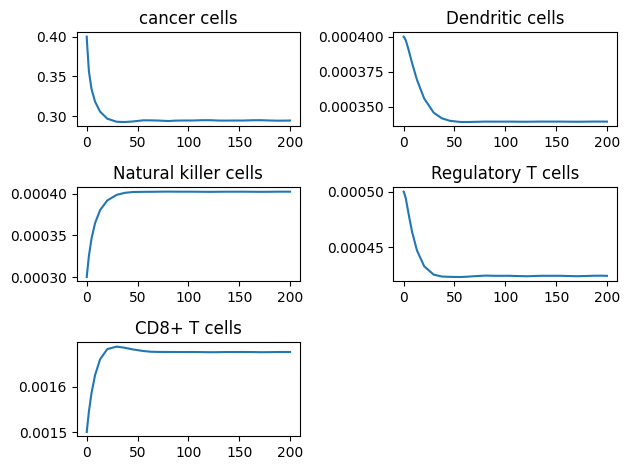

In [8]:
t = sol.t
y = sol.y


fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendritic cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
# SDEs
!pip3 install sdeint
import sdeint
from sdeint import itoint
from sdeint import itoEuler

# need a noise term
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.0,0.2]
lambda_C,C_M,eta_8,T_8,eta_N,N,d_C,lambda_DC,D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,T8_0,K_D,K_Tr,noise_param,noise_NK_prod = params
def cancer_ode_parametrised(y,t):
    return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,(1-noise_NK_prod)*sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr)
def G(y,t):
    C,D,N,Tr,T8 = y
    return np.diag((noise_param*lambda_C*C*(1-C/C_M),0,noise_NK_prod*sigma_N,0,0,))


In [10]:
t = np.arange(tspan[0],tspan[1],0.001)
sol = itoEuler(cancer_ode_parametrised, G, C0, t)

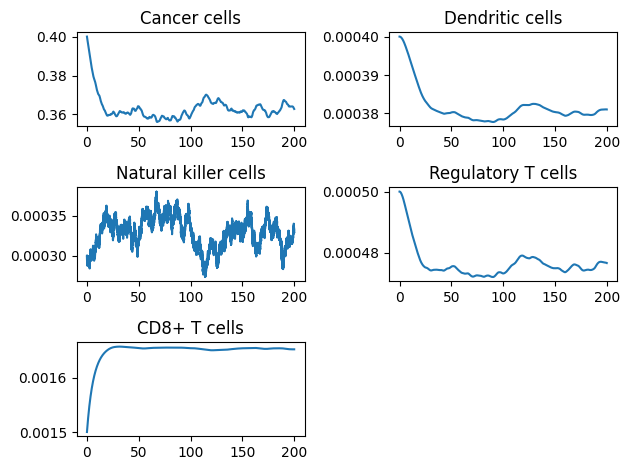

In [25]:
y = []
i = 0
for i in range(sol.shape[1]):
    y.append(sol[:,i])
fig,ax = plt.subplots(3,2)
cancer = ax[0,0]
cancer.plot(t,y[0])
cancer.set_title('Cancer cells')
D_cells = ax[0,1]
D_cells.plot(t,y[1])
D_cells.set_title('Dendritic cells')
NK_cells = ax[1,0]
NK_cells.plot(t,y[2])
NK_cells.set_title('Natural killer cells')
Treg = ax[1,1]
Treg.plot(t,y[3])
Treg.set_title('Regulatory T cells')
T8 = ax[2,0]
T8.plot(t,y[4])
T8.set_title('CD8+ T cells')
extra_plot = ax[2,1]
extra_plot.set_visible(False)
plt.tight_layout()
plt.show()


In [12]:
!pip3 install pandas
import pandas as pd

In [21]:
print(df['Condition'].unique())
print (df['Condition'].value_counts())

<StringArray>
[       'day7',         'end',        'day3', 'Apobec_day3',     'UV_day3',
      'UV_end',     'UV_day7',  'Apobec_end', 'Apobec_day7']
Length: 9, dtype: str
Condition
end            49
day3           47
UV_end         19
UV_day7        18
day7           16
UV_day3        14
Apobec_day3    13
Apobec_end      8
Apobec_day7     8
Name: count, dtype: int64


In [23]:
subset_df = df[(df['Mouse_treatment'] == 'no_treatment') & (df['Cell_Line'] == 'KPB25L')]
subset_df

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,GSM_ID,Cell_Line
1,SRX5100686,0.030451,0.010853,0.000000,0.003228,no_treatment,day7,day7,GSM3554692,KPB25L
2,SRX5100687,0.030096,0.010989,0.000349,0.004048,no_treatment,day7,day7,GSM3554693,KPB25L
3,SRX5100692,0.030466,0.010471,0.000333,0.004030,no_treatment,day7,day7,GSM3554694,KPB25L
4,SRX5100693,0.031649,0.008606,0.000000,0.003357,no_treatment,day7,day7,GSM3554695,KPB25L
8,SRX5100597,0.029152,0.007065,0.000000,0.002797,no_treatment,end,end,GSM3554699,KPB25L
9,SRX5100596,0.032315,0.010025,0.000000,0.003605,no_treatment,day3,day3,GSM3554700,KPB25L
10,SRX5100599,0.025473,0.006424,0.000000,0.002765,no_treatment,end,end,GSM3554701,KPB25L
11,SRX5100598,0.025723,0.007226,0.000000,0.003291,no_treatment,day3,day3,GSM3554702,KPB25L
12,SRX5100618,0.025649,0.005015,0.000000,0.002848,no_treatment,day3,day3,GSM3554703,KPB25L
13,SRX5100617,0.027570,0.007122,0.000000,0.003442,no_treatment,day3,day3,GSM3554704,KPB25L


In [24]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [ ]:
def cancer_ode(t,y,lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr):
    C,D,N,Tr,T8 = y
    dC = lambda_C*C*(1-C/C_M) - eta_8*T8*C - eta_8*N*C-d_C*C
    dD = lambda_DC*D_0*C/(C+K_C)-d_D*D
    dN = sigma_N - d_N*N - gamma_N*Tr*N + a_C*N*C/(1+C/beta_1 + N/beta_2)
    dTr = -d_Tr*Tr + lambda_Tr*Tr_0*C/(K_C+C)
    dT8 = -d_T8 * T8 + lambda_T8 * T8_0*D/(K_D+D)/(1+Tr/K_Tr)
    return np.array((dC,dD,dN,dTr,dT8,))

# lambda_C = growth rate tumour 
# C_M = carrying capacity of the tumour cells 
# eta_8 = killing rate of tumour cells by CD8+ T cells 
# eta_N = killing rate of tumour cells by NK cells 
# d_C = death rate of tumour cells 
# lambda_DC = activation rate of DCs by tumour 
# D_0 = baseline levels of inactive DCs 
# K_C = half saturation of tumour cells 
# d_D = death rate of DCs
# sigma_N = influx of NK cells in tumour
# d_N = death rate of NK cells
# gamma_N = killing rate of NK cells by Tregs
# a_C = recruitment rate of NK cells by tumour cells 
# beta_1 = half saturation of tumour cells for the recruitment of NK cells 
# beta_2 = half saturtion of NK cells for the recruitment of NK cells 
# d_Treg = death rate of Tregs 
# lambda_Tregs = activation rate of Tregs by tumour 
# T_10 = baselines levels of regulatory T cell precursors 
# d_T8 = death rate of CD8+ T cells 
# lambda_T8 = activation rate of CD8+ T cells by DCs
# T80 = baseline levels of CD8+ T cell precursors 
# K_Tregs = inhibition of function of CD8+ T cells by Tregs 
# K_D = half saturation of DCs 
    
params = [1.5,0.8,328.28,0.0015,300,0.0003,0.17,4.0,2e-5,0.4,0.1,5e-5,0.1,150,0.5,0.4,2e-4,0.2,0.5,4e-4,0.18,5.4,2e-4,2.5e-4,4e-4,0.1]
lambda_C,C_M,eta_8,T_8,eta_N,N,d_C,lambda_DC,D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,T8_0,K_D,K_Tr,noise_param = params
def cancer_ode_parametrised(t,y):
    return cancer_ode(t,y,(1-noise_param)*lambda_C,C_M,eta_8,eta_N,d_C,lambda_DC,
               D_0,K_C,d_D,sigma_N,d_N,gamma_N,a_C,beta_1,
               beta_2,d_Tr,lambda_Tr,Tr_0,d_T8,lambda_T8,
              T8_0,K_D,K_Tr) 